In [2]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [4]:
snapnum = 40

In [5]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [6]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [7]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [8]:
h = 0.6774

In [9]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [10]:
group_sfr = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [10]:
m200c = np.log10((10**np.array(f["M200c"]))*h)
c200c = f["c200c"]

In [166]:
len(c200c)

20332985

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


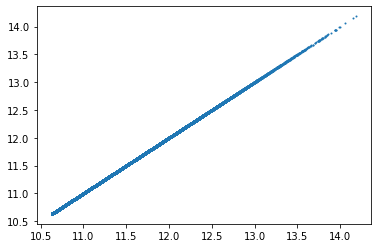

In [22]:
plt.scatter(np.log10(halos["Group_M_Crit200"]*1e10), m200c, s=1)

Text(0, 0.5, 'M200c')

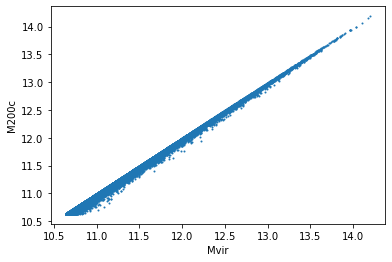

In [28]:
plt.scatter(mvir, m200c, s=1)
plt.xlabel("Mvir")
plt.ylabel("M200c")

Text(0, 0.5, 'log(conc)')

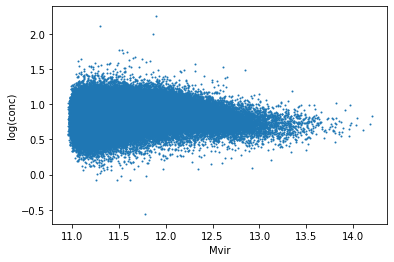

In [31]:
plt.scatter(mvir, np.log10(c200c), s=1)
plt.xlabel("Mvir")
plt.ylabel("log(conc)")

In [82]:
mask1 = (mvir > 13) & (mvir < 13.2) & (group_sfr > -5) & (np.array(c200c) > 0)

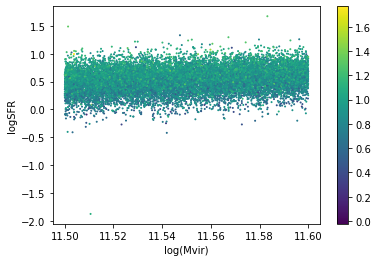

In [43]:
plt.scatter(mvir[mask1] , group_sfr[mask1], c=np.log10(c200c[mask1]), s=1)
plt.xlabel("log(Mvir)")
plt.ylabel("logSFR")
plt.colorbar()

In [86]:
from scipy import stats

stats.pearsonr(group_sfr[mask1],np.log10(c200c[mask1]))

NameError: name 'mask1' is not defined

Text(0, 0.5, 'log(conc)')

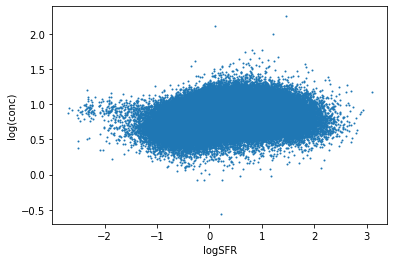

In [91]:
plt.scatter(group_sfr, np.log10(c200c), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(conc)")

Text(0, 0.5, 'log(conc)')

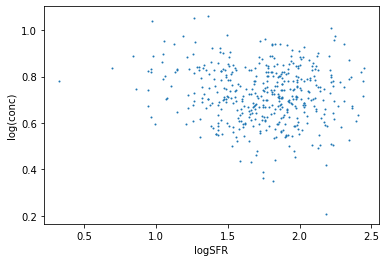

In [84]:
plt.scatter(group_sfr[mask1], np.log10(c200c[mask1]), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(conc)")

### Looking at subhalo SFRs

In [11]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [12]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [13]:
mask0 = halos["GroupFirstSub"]==-1

In [14]:
subhalos["SubhaloSFR"][-1] # If halos["GroupFirstSub"]==-1 then cent SFR will be 0

0.0

In [28]:
#cent_sfr = np.log10(subhalos["SubhaloSFR"][halos["GroupFirstSub"]])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [15]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [16]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [97]:
#cent_sfrs = subhalos["SubhaloSFR"][cent_mask_all]

In [572]:
cent_mass1 = subhalos["SubhaloMass"][cent_mask_all]*1e10

In [573]:
cent_mass = np.zeros(len(mvir))
cent_mass[halos["GroupFirstSub"]>-1] = cent_mass1
cent_mass = np.log10(cent_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [136]:
Mbh_sub = np.log10(subhalos["SubhaloBHMass"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [137]:
Mbh_cent =  np.zeros(len(mvir))
Mbh_cent[halos["GroupFirstSub"]>-1] = Mbh_sub[cent_mask_all]

In [436]:
logM = 11.9
mask2 = (mvir > logM) & (mvir < logM+0.1) & (cent_sfr > -5) & (np.array(c200c) > 0)

In [437]:
stats.spearmanr(cent_sfr[mask2],np.log10(c200c[mask2]))

SpearmanrResult(correlation=0.3187090621129215, pvalue=1.8930555125816902e-157)

In [438]:
stats.pearsonr(cent_sfr[mask2],np.log10(c200c[mask2]))

(0.15948815833732935, 2.8161499309100848e-39)

Text(0, 0.5, 'log(conc)')

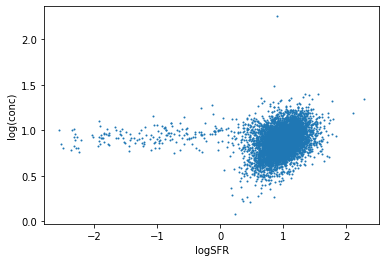

In [439]:
plt.scatter(cent_sfr[mask2], np.log10(c200c[mask2]), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(conc)")

### Compute correlation coefficient for different mvir

In [162]:
dlogM = 0.1
mbin_cents = np.arange(8,15,dlogM)
coef_list = []
#frac_list = []
for mcent in mbin_cents:
    mask = (mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) & (np.array(c200c) > 0) & (Mbh_cent > 8.2)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef = stats.spearmanr(group_sfr[mask],np.log10(c200c[mask]))[0]
    coef_list.append(coef)

Text(0, 0.5, 'Fraction with c200c not nan')

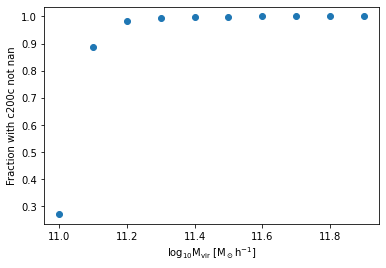

In [141]:
plt.scatter(mbin_cents[30:40], frac_list[30:40])
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Fraction with c200c not nan")

Text(0, 0.5, 'Spearman correlation coefficient(SFR$_{group}$, conc)')

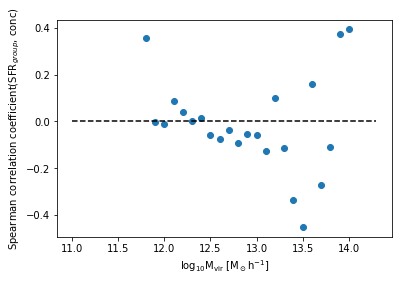

In [163]:
plt.scatter(mbin_cents[:-9], coef_list[:-9])
plt.plot([11,14.3], [0,0], linestyle="dashed", c="k")
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Spearman correlation coefficient(SFR$_{group}$, conc)")

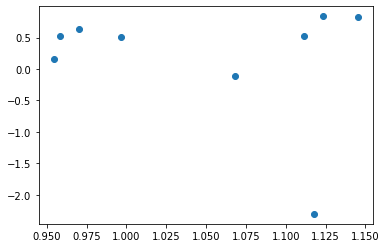

In [157]:
mcent = 11.7
mask = (mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) & (np.array(c200c) > 0) & (Mbh_cent > 8)
plt.scatter(np.log10(c200c[mask]), cent_sfrs[mask])

Text(0, 0.5, 'PDF for number of halos without c200c values')

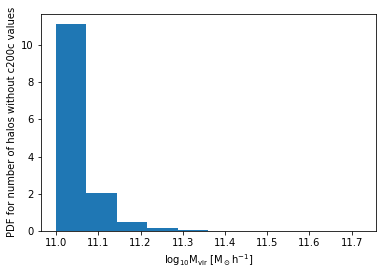

In [126]:

mask0 = (np.isnan(c200c) == True) & (mvir > 11)
plt.hist(mvir[mask0], density=True)
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("PDF for fraction of halos without c200c values")

In [326]:
bins = np.arange(11,15,0.1)

frac_list = []
for m in bins:
    mask0 = (np.isnan(c200c) == False) & (mvir > m-0.5) & (mvir < m+0.5)
    masktot =  (mvir > m-0.5) & (mvir < m+0.5)
    frac = np.sum(mask0)/np.sum(masktot)
    frac_list.append(frac)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in long_scalars
  import sys


Text(0, 0.5, 'Frac(conc is not nan)')

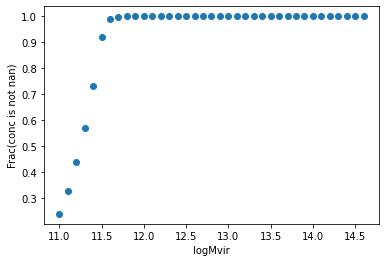

In [328]:
plt.scatter(bins, frac_list)
plt.xlabel("logMvir")
plt.ylabel("Frac(conc is not nan)")

In [ ]:
plt.scatter(mbin)

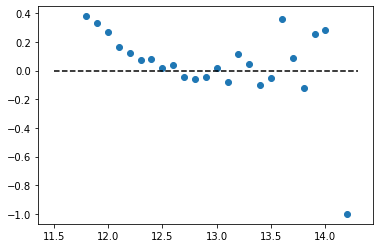

In [113]:
plt.scatter(mbin_cents, coef_list)
plt.plot([11.5,14.3], [0,0], linestyle="dashed", c="k")

In [109]:
stats.pearsonr(cent_sfr[mask2],np.log10(c200c[mask2]))

(0.3358424739637768, 3.361871772598567e-126)

In [181]:
mfof = np.log10(halos["GroupMass"]*1e10)

In [184]:
mdm = np.log10(halos["GroupMassType"][:,1]*1e10)

In [194]:
mdm_sub = subhalos["SubhaloMassType"][:,1]

In [203]:
mdm_cent1 = np.log10(mdm_sub[cent_mask_all]*1e10)
mdm_cent = np.zeros(len(mvir))
mdm_cent[halos["GroupFirstSub"]>-1] = mdm_cent1

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [215]:
h = 0.6774
mpart = 5.9 * 1e7 * 0.6774
mpart = 0.00398342749867548 * 1e10
npart = 2000
min_mass = np.log10(mpart*npart)
print(min_mass)

10.901286912756953


In [217]:
m200c

array([13.98592519, 14.18676019, 14.15564019, ...,         nan,
               nan,         nan])

In [225]:
m200c_main = np.log10(halos["Group_M_Crit200"] *1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


Text(0, 0.5, 'logM200c')

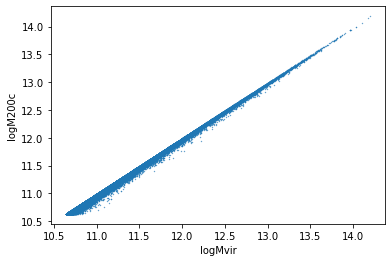

In [234]:
plt.scatter(mvir, m200c, s=0.1)
plt.xlabel("logMvir")
plt.ylabel("logM200c")

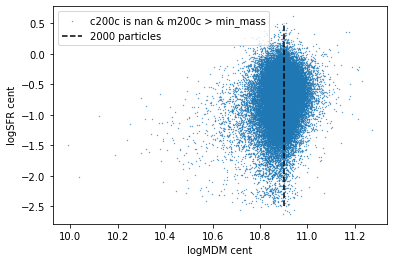

In [232]:
masknan = (np.isnan(c200c) == True) & (m200c_main > min_mass)
plt.scatter(mdm_cent[masknan], cent_sfr[masknan], s=0.1, label="c200c is nan & m200c > min_mass")
plt.vlines(min_mass, ymin=-2.5, ymax=0.5, linestyle="dashed", color="k", label="2000 particles")
plt.xlabel("logMDM cent")
plt.ylabel("logSFR cent")
plt.legend()

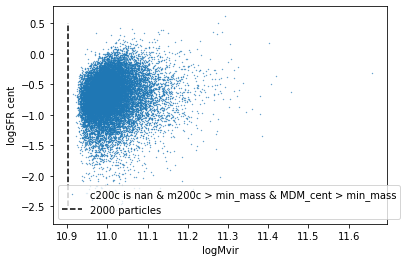

In [238]:
masknan = (np.isnan(c200c) == True) & (m200c_main > min_mass) & (mdm_cent > min_mass)
plt.scatter(mvir[masknan], cent_sfr[masknan], s=0.1, label="c200c is nan & m200c > min_mass & MDM_cent > min_mass")
plt.vlines(min_mass, ymin=-2.5, ymax=0.5, linestyle="dashed", color="k", label="2000 particles")
plt.xlabel("logMvir")
plt.ylabel("logSFR cent")
plt.legend()

In [240]:
np.array(c200c)

array([6.36285137, 6.76371798, 5.21853346, ...,        nan,        nan,
              nan])

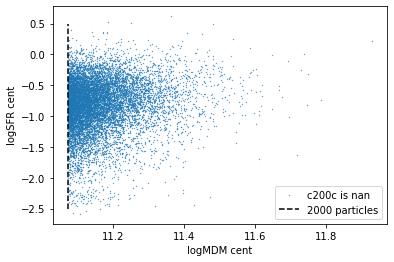

In [210]:
masknan = (np.isnan(c200c) == True) & (mdm > min_mass)
plt.scatter(mdm[masknan], cent_sfr[masknan], s=0.1, label="c200c is nan")
plt.vlines(min_mass, ymin=-2.5, ymax=0.5, linestyle="dashed", color="k", label="2000 particles")
plt.xlabel("logMDM cent")
plt.ylabel("logSFR cent")
plt.legend()

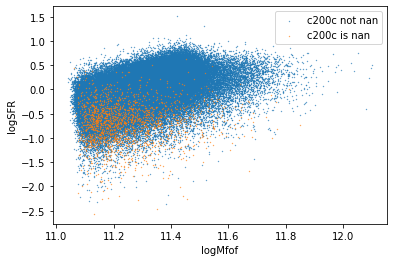

<Figure size 432x288 with 0 Axes>

In [191]:
masknan = (np.isnan(c200c) == False) & (mvir > 11.1) & (mvir < 11.5)
plt.scatter(mfof[masknan], cent_sfr[masknan], s=0.1, label="c200c not nan")
masknan = (np.isnan(c200c) == True) & (mvir > 11.1) & (mvir < 11.5)
plt.scatter(mfof[masknan], cent_sfr[masknan], s=0.1, label="c200c is nan")
plt.xlabel("logMfof")
plt.ylabel("logSFR")
plt.legend()
plt.show()
plt.clf()

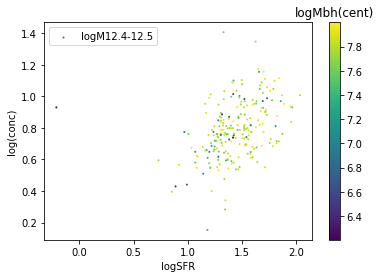

In [397]:
logM = 12.4
mask2 = (mvir> logM) & (mvir < logM+0.1) & (Mbh_cent < 8) & (np.array(c200c) > 0) & (cent_sfr > -5)
fig,ax=plt.subplots()
plt.scatter(cent_sfr[mask2], np.log10(c200c[mask2]), c=Mbh_cent[mask2], s=1, label=f"logM{logM}-{np.round(logM+0.1,1)}")
plt.xlabel("logSFR")
plt.ylabel("log(conc)")
cbar = plt.colorbar()
cbar.ax.set_title("logMbh(cent)")
plt.legend()

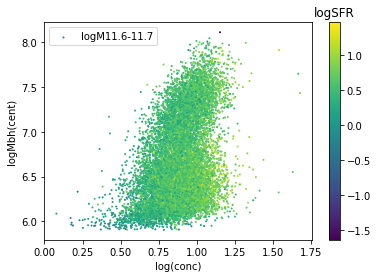

In [487]:
logM = 11.6
mask2 = (mvir> logM) & (mvir < logM+0.1) & (np.array(c200c) > 0) & (cent_sfr > -5) & (Mbh_cent > 0)
fig,ax=plt.subplots()
plt.scatter(np.log10(c200c[mask2]), Mbh_cent[mask2], c=cent_sfr[mask2], s=1, label=f"logM{logM}-{np.round(logM+0.1,1)}")
plt.xlabel("log(conc)")
plt.ylabel("logMbh(cent)")
cbar = plt.colorbar()
cbar.ax.set_title("logSFR")
plt.legend()

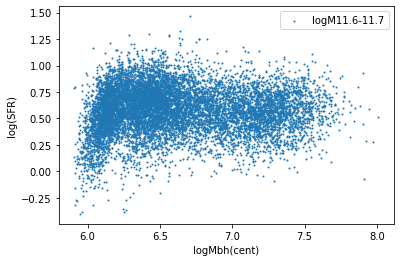

In [490]:
logM = 11.6
mask2 = (mvir> logM) & (mvir < logM+0.1) & (np.log10(c200c) > 0.9) &(np.log10(c200c) < 1) & (cent_sfr > -5) & (Mbh_cent>0)#& (Mbh_cent <8) 
fig,ax=plt.subplots()
plt.scatter(Mbh_cent[mask2], cent_sfr[mask2], s=1, label=f"logM{logM}-{np.round(logM+0.1,1)}")
plt.ylabel("log(SFR)")
plt.xlabel("logMbh(cent)")
#cbar = plt.colorbar()
#cbar.ax.set_title("logSFR")
plt.legend()

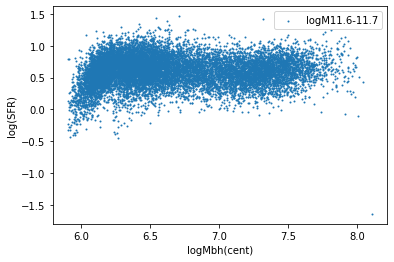

In [481]:
logM = 11.6
mask2 = (mvir> logM) & (mvir < logM+0.1) & (np.array(c200c) > 0) & (cent_sfr > -5) & (Mbh_cent>0)#& (Mbh_cent <8) 
fig,ax=plt.subplots()
plt.scatter(Mbh_cent[mask2], cent_sfr[mask2], s=1, label=f"logM{logM}-{np.round(logM+0.1,1)}")
plt.ylabel("log(SFR)")
plt.xlabel("logMbh(cent)")
#cbar = plt.colorbar()
#cbar.ax.set_title("logSFR")
plt.legend()

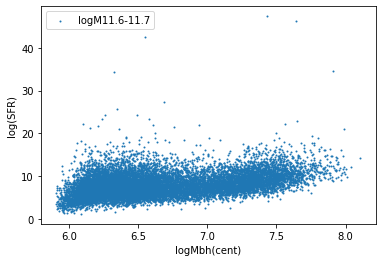

In [480]:
logM = 11.6
mask2 = (mvir> logM) & (mvir < logM+0.1) & (np.array(c200c) > 0) & (cent_sfr > -5) & (Mbh_cent>0)#& (Mbh_cent <8) 
fig,ax=plt.subplots()
plt.scatter(Mbh_cent[mask2], c200c[mask2], s=1, label=f"logM{logM}-{np.round(logM+0.1,1)}")
plt.ylabel("log(SFR)")
plt.xlabel("logMbh(cent)")
#cbar = plt.colorbar()
#cbar.ax.set_title("logSFR")
plt.legend()

In [458]:
np.array(c200c)

array([6.36285137, 6.76371798, 5.21853346, ...,        nan,        nan,
              nan])

In [491]:
stats.spearmanr(Mbh_cent[mask2],cent_sfr[mask2])

SpearmanrResult(correlation=0.0384991389912016, pvalue=9.769881570894254e-05)

In [484]:
stats.pearsonr(Mbh_cent[mask2],cent_sfr[mask2])

(-0.1979365816723656, 2.9427092850945895e-31)

[ 1.42444306  5.53777988  6.57141918  8.02683039 25.50265607]


Text(0, 0.5, 'PDF(logM12.4-12.5)')

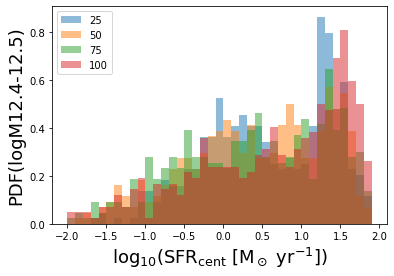

In [368]:
bins=np.arange(-2, 2, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
logM = 12.4
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(c200c[mask2])
mask_high = c200c[mask2] > median
mask_low = c200c[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(c200c[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (c200c[mask2] > percentiles[i]) & (c200c[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(cent_sfr[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i+1]}", alpha=0.5)#,histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend()
plt.xlabel(r'log$_{10}$(SFR$_{\rm cent}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF(logM{logM}-{np.round(logM+0.1,1)})", fontsize=18)

In [280]:
min(c200c[mask2])

1.5416070333464271

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


Text(0, 0.5, 'logSFR')

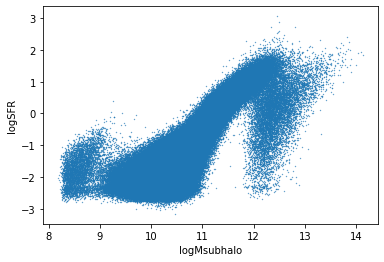

In [98]:
plt.scatter(np.log10(cent_mass), np.log10(cent_sfrs), s=0.1)
plt.xlabel("logMsubhalo")
plt.ylabel("logSFR")

In [99]:
mask_test = (np.log10(cent_mass) < 10) & (cent_sfrs > 0)
np.sum(mask_test)

160491

### Satellite SFR

In [17]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [18]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [31]:
mask_nonzero_sat = (sat_mass > 0) & (sat_sfrs > 0)

In [265]:
stats.pearsonr(np.log10(sat_mass[mask_nonzero_sat]),np.log10(sat_sfrs[mask_nonzero_sat]))

(0.49713513170496204, 0.0)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


Text(0, 0.5, 'logSFR')

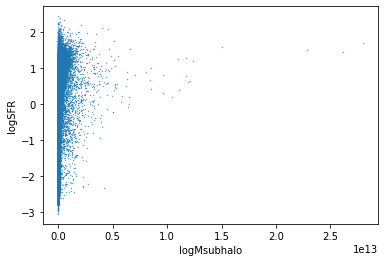

In [90]:
plt.scatter(sat_mass, np.log10(sat_sfrs), s=0.1)
plt.xlabel("logMsubhalo")
plt.ylabel("logSFR")

In [91]:
mask_test = (np.log10(sat_mass) < 10) & (sat_sfrs > 0)
np.sum(mask_test)

345716

In [19]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [20]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [21]:
sum_sfrs = np.zeros(len(group_sfr))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [22]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [23]:

sum_sat_mass = np.zeros(len(group_sfr))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


NameError: name 'np' is not defined

In [44]:
mask_mass = (sum_sat_mass > 0) & (sum_sfrs > -5) & (mvir > 12) & (mvir < 12.1)

In [45]:
stats.pearsonr(sum_sat_mass[mask_mass]-mvir[mask_mass], sum_sfrs[mask_mass])


NameError: name 'stats' is not defined

Text(0, 0.5, 'logSFR')

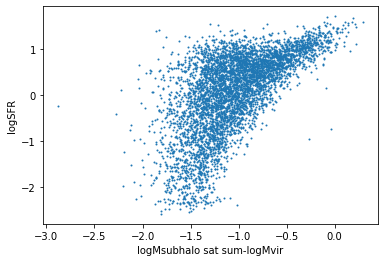

In [46]:
plt.scatter(sum_sat_mass[mask_mass]-mvir[mask_mass], sum_sfrs[mask_mass], s=1)
plt.xlabel("logMsubhalo sat sum-logMvir")
plt.ylabel("logSFR")

In [36]:
logM = 13.6
dlogM = 0.2
mask_mass = (sum_sat_mass > 0) & (sum_sfrs > -5) & (mvir > logM) & (mvir < logM+dlogM)

In [37]:
np.sum(mask_mass)

31

In [1057]:
coef = stats.pearsonr(sum_sat_mass[mask_mass], group_sfr[mask_mass])

(0.45420283560905433, 0.0001633024847404955)


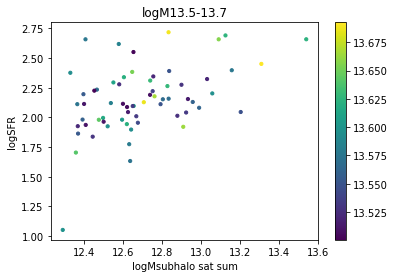

In [1058]:
plt.scatter(sum_sat_mass[mask_mass], group_sfr[mask_mass], s=10, c=mvir[mask_mass])
plt.xlabel("logMsubhalo sat sum")
plt.ylabel("logSFR")
plt.colorbar()
plt.title(f"logM{logM}-{logM+dlogM:.1f}")
print(coef)


In [1059]:
coef = stats.pearsonr(mvir[mask_mass], group_sfr[mask_mass])

(0.17142779994897078, 0.1755949692634593)


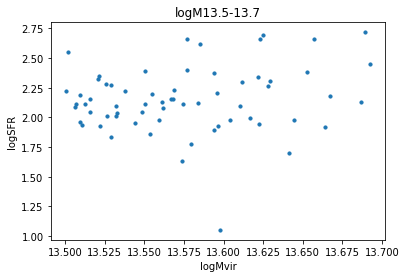

In [1060]:
plt.scatter(mvir[mask_mass], group_sfr[mask_mass], s=10)
plt.xlabel("logMvir")
plt.ylabel("logSFR")
plt.title(f"logM{logM}-{logM+dlogM:.1f}")
print(coef)


In [803]:
coef = stats.pearsonr(c200c[mask_mass], group_sfr[mask_mass])

ValueError: array must not contain infs or NaNs

(0.222630033266217, 1.0566896596151391e-225)


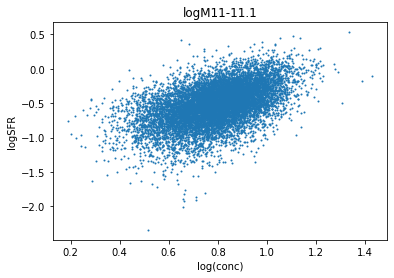

In [804]:
plt.scatter(np.log10(c200c[mask_mass]), group_sfr[mask_mass], s=1)
plt.xlabel("log(conc)")
plt.ylabel("logSFR")
plt.title(f"logM{logM}-{logM+dlogM:.1f}")
print(coef)

Text(0, 0.5, 'log(conc)')

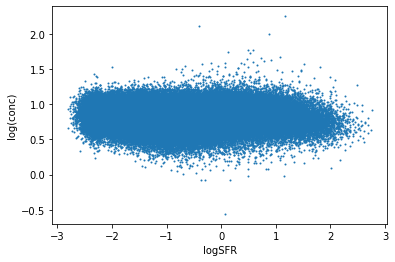

In [329]:
plt.scatter(sum_sfrs, np.log10(c200c), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(conc)")

SpearmanrResult(correlation=-0.3598930370762343, pvalue=0.0)

SpearmanrResult(correlation=-0.3598930370762343, pvalue=0.0)


Text(0, 0.5, 'Group SFR')

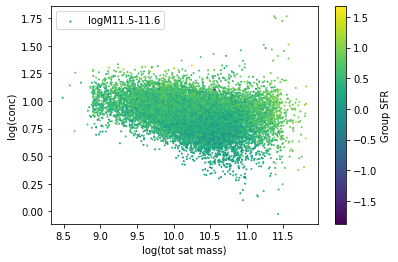

In [581]:
logM = 11.5
logM1 = 9
mask = (mvir > logM) & (mvir < logM+0.1) #& (sum_sat_mass > logM1)& (sum_sat_mass < logM1+0.5)

plt.scatter(sum_sat_mass[mask], np.log10(c200c[mask]), s=1,  label=f"logM{logM}-{logM+0.1:.1f}", c=group_sfr[mask])
plt.xlabel("log(tot sat mass)")
plt.ylabel("log(conc)")
plt.legend()
coef = stats.spearmanr(sum_sat_mass[mask & (np.isnan(c200c) == False)],c200c[mask&(np.isnan(c200c) == False)] )
print(coef)
cbar = plt.colorbar()
cbar.ax.set_ylabel("Group SFR")

In [ ]:
plt.scatter(np.log10(c200c[mask]), group_sfr[mask],s=1)
coef = stats.spearmanr(c200c[mask & (np.isnan(c200c) == False)],group_sfr[mask&(np.isnan(c200c) == False)] )
print(coef)
plt.xlabel("log(conc)")
plt.ylabel("Group SFR")

SpearmanrResult(correlation=-0.07743345290965231, pvalue=3.3401485972504396e-23)


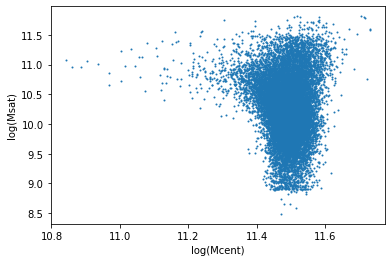

In [585]:
plt.scatter(cent_mass[mask], sum_sat_mass[mask], s=1)
        
coef = stats.spearmanr(cent_mass[mask],sum_sat_mass[mask] )

plt.xlabel("log(Mcent)")
plt.ylabel("log(Msat)")
print(coef)                  

SpearmanrResult(correlation=0.2322619705207663, pvalue=2.0032742789213646e-199)


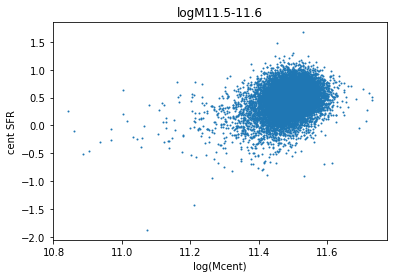

In [582]:
plt.title(f"logM{logM}-{logM+0.1:.1f}")
plt.scatter(cent_mass[mask], cent_sfrs[mask],s=1)

coef = stats.spearmanr(cent_mass[mask],cent_sfrs[mask] )

plt.xlabel("log(Mcent)")
plt.ylabel("cent SFR")
print(coef)

SpearmanrResult(correlation=0.20004044052626938, pvalue=2.1052109377999088e-147)


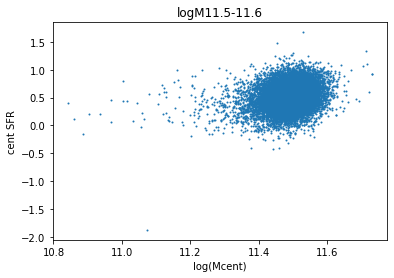

In [587]:
plt.title(f"logM{logM}-{logM+0.1:.1f}")
plt.scatter(cent_mass[mask], group_sfr[mask],s=1)

coef = stats.spearmanr(cent_mass[mask],group_sfr[mask] )

plt.xlabel("log(Mcent)")
plt.ylabel("cent SFR")
print(coef)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


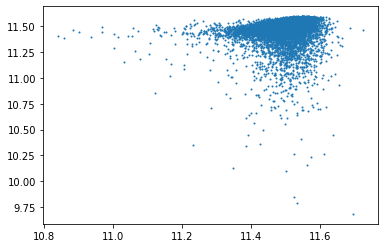

In [584]:
plt.scatter(cent_mass[mask], np.log10(10**mvir[mask] - 10**sum_sat_mass[mask]), s=1)

SpearmanrResult(correlation=-0.08550598766084967, pvalue=2.9012624493236856e-08)


Text(0, 0.5, 'Group SFR')

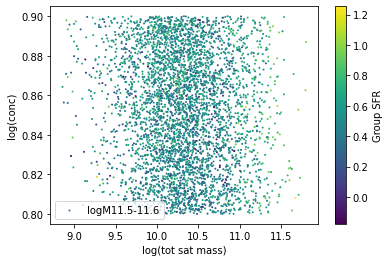

In [534]:
logM = 11.5
c1=0.8
mask = (mvir > logM) & (mvir < logM+0.1) & (np.log10(c200c) > c1)& (np.log10(c200c) < c1+0.1)

plt.scatter(sum_sat_mass[mask], np.log10(c200c[mask]), s=1,  label=f"logM{logM}-{logM+0.1:.1f}", c=group_sfr[mask])
plt.xlabel("log(tot sat mass)")
plt.ylabel("log(conc)")
plt.legend()
coef = stats.spearmanr(sum_sat_mass[mask & (np.isnan(c200c) == False)],c200c[mask&(np.isnan(c200c) == False)] )
print(coef)
cbar = plt.colorbar()
cbar.ax.set_ylabel("Group SFR")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


SpearmanrResult(correlation=0.09646727442696086, pvalue=3.811406731260984e-10)


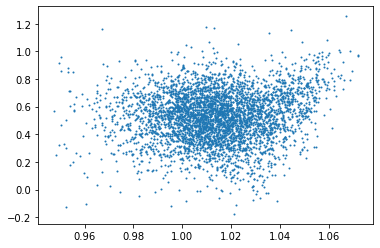

In [535]:
plt.scatter(np.log10(sum_sat_mass[mask]), group_sfr[mask],s=1)
coef = stats.spearmanr(sum_sat_mass[mask & (np.isnan(c200c) == False)],group_sfr[mask&(np.isnan(c200c) == False)] )
print(coef)

SpearmanrResult(correlation=-0.34499915475105786, pvalue=0.0)


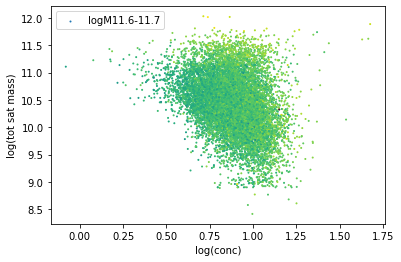

In [511]:
logM = 11.6

mask = (mvir > logM) & (mvir < logM+0.1)

plt.scatter(np.log10(c200c[mask]),sum_sat_mass[mask],  s=1,  label=f"logM{logM}-{logM+0.1:.1f}", c=group_sfr[mask])
plt.ylabel("log(tot sat mass)")
plt.xlabel("log(conc)")
plt.legend()
coef = stats.spearmanr(sum_sat_mass[mask & (np.isnan(c200c) == False)],c200c[mask&(np.isnan(c200c) == False)] )
print(coef)

In [ ]:

plt.scatter(sum_sfrs, np.log10(c200c), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(conc)")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in true_divide
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


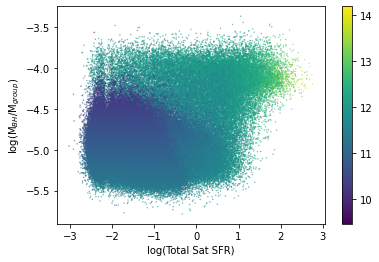

In [81]:
plt.scatter(sum_sfrs, np.log10(halos["GroupBHMass"]/halos["Group_M_TopHat200"]), c=mvir, s=0.1)
plt.xlabel("log(Total Sat SFR)")
plt.ylabel("log(M$_{BH}$/M$_{group}$)")
#plt.ylabel("log(M$_{BH}$)")
plt.colorbar()

In [335]:
mask3 = (mvir > 13) & (mvir < 13.1) & (sum_sfrs > -5) & (np.array(c200c) > 0) & (np.array(Mdyn) > 0)

In [336]:
stats.pearsonr(sum_sfrs[mask3],np.log10(c200c[mask3]))

(-0.15380715413912224, 0.01432824183157467)

Text(0, 0.5, 'log(conc)')

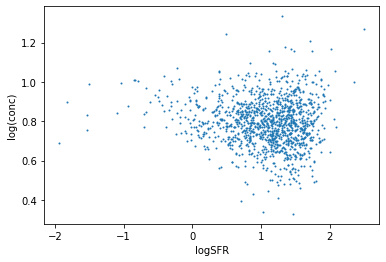

In [334]:
plt.scatter(sum_sfrs[mask3], np.log10(c200c[mask3]), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(conc)")

[ 9.14787385 10.71791621 10.96825833 11.26164264 12.34553928]


Text(0, 0.5, 'PDF(logM12-12.1)')

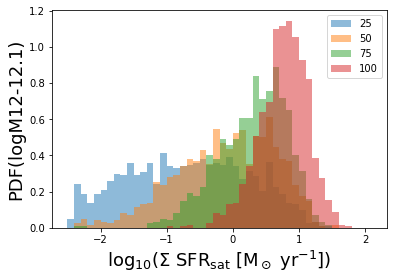

In [38]:
bins=np.arange(-2.5, 2.2, 0.1)
logM = 12
mask2 = (sum_sat_mass > 0) & (sum_sfrs > -5) & (mvir > logM) & (mvir < logM+0.1)
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(sum_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i+1]}", alpha=0.5)#,histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend()
plt.xlabel(r'log$_{10}$($\Sigma$ SFR$_{\rm  sat}}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF(logM{logM}-{np.round(logM+0.1,1)})", fontsize=18)

[ 9.14787385 10.71791621 10.96825833 11.26164264 12.34553928]


Text(0, 0.5, 'PDF(logM12-12.1)')

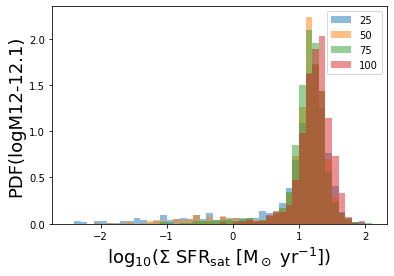

In [40]:
bins=np.arange(-2.5, 2.2, 0.1)
logM = 12
mask2 = (sum_sat_mass > 0) & (sum_sfrs > -5) & (mvir > logM) & (mvir < logM+0.1)
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfr[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i+1]}", alpha=0.5)#,histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend()
plt.xlabel(r'log$_{10}$($\Sigma$ SFR$_{\rm  sat}}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF(logM{logM}-{np.round(logM+0.1,1)})", fontsize=18)

### Satellite SFR and Satellite subhalo mass correlation

### Correlation with halo accretion rate

In [83]:
Mdyn = f["M_acc_dyn"]

In [824]:
logM = 11.1
mask4 = (mvir > logM) & (mvir < logM+0.1) & (sum_sfrs > -5) & (np.array(c200c) > 0) & (np.array(Mdyn) > 0)

In [825]:
stats.pearsonr(sum_sfrs[mask4],np.log10(Mdyn[mask4])-mvir[mask4])

(0.18945741880586459, 1.9243914637168982e-136)

Text(0.5, 0, 'log(dM/dtdyn)')

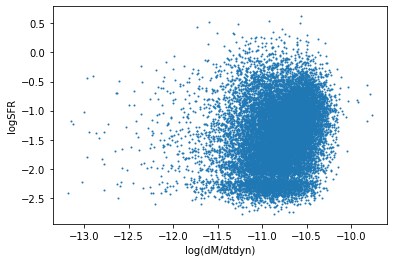

In [826]:
plt.scatter( np.log10(Mdyn[mask4])-mvir[mask4], sum_sfrs[mask4], s=1)
plt.ylabel("logSFR")
plt.xlabel("log(dM/dtdyn)")

#### Central SFR

In [71]:
logM = 12
mask5 = (mvir > logM) & (mvir < logM+0.1) & (sum_sfrs > -5)  & (np.log10(Mdyn) > 0.5) & (np.log10(Mdyn) < 0.6) & (cent_sfr > -5)

NameError: name 'Mdyn' is not defined

(0.4062179395388514, 4.4074644861448645e-89)

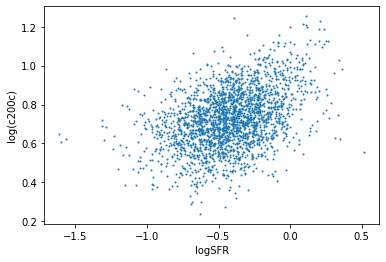

In [909]:
plt.scatter(group_sfr[mask5], np.log10(c200c[mask5]), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(c200c)")
stats.pearsonr(group_sfr[mask5],np.log10(c200c[mask5]))

In [910]:
stats.pearsonr(group_sfr[mask5],np.log10(Mdyn[mask5]))

(-0.04980699991281135, 0.01885061033899802)

Text(0, 0.5, 'log(dM/dtdyn)')

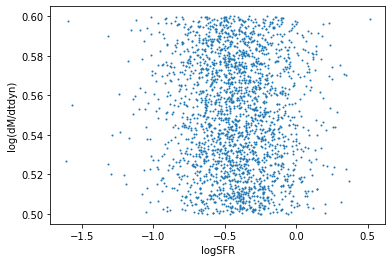

In [911]:
plt.scatter(group_sfr[mask5], np.log10(Mdyn[mask5]), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(dM/dtdyn)")

#### Group SFR

In [72]:
group_coef = stats.pearsonr(group_sfr[mask5],np.log10(Mdyn[mask5]))

NameError: name 'mask5' is not defined

In [ ]:
plt.scatter(group_sfr[mask5], np.log10(Mdyn[mask5]), s=1)
plt.xlabel("logSFR")
plt.ylabel("log(dM/dtdyn)")
plt.title(f"{logM}-{logM+0.1}")
print(group_coef)

In [27]:
import scipy.stats as stats

In [46]:
sfr_types = [cent_sfrs, sum_sfrs, group_sfr]

In [50]:
sfr_type_names = ["Central", "Satellite", "Group"]

In [81]:
dlogM = 0.1
mbin_cents = np.arange(10,14.5,dlogM)

coef_lists =[]
for itype in range(3):
    coef_list = []
    for mcent in mbin_cents:
        mask = (mvir > mcent - dlogM) & (mvir < mcent + dlogM) & (group_sfr > -5) #& (np.isnan(Mdyn)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        coef = stats.spearmanr(sum_sat_mass[mask],sfr_types[itype][mask])[0]
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
    coef_lists.append(coef_list)

14.199999999999985
14.299999999999985
14.399999999999984
14.199999999999985
14.299999999999985
14.399999999999984
14.199999999999985
14.299999999999985
14.399999999999984


0.9999999999999999
5


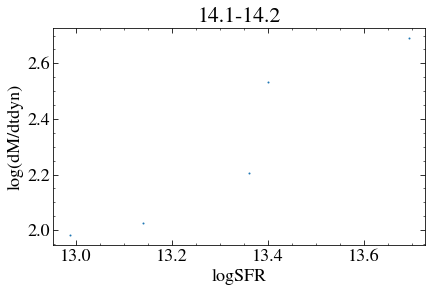

In [79]:
logM = 14.1
dlogM = 0.1
mask5 = (mvir > logM - dlogM) & (mvir < logM + dlogM) & (group_sfr > -5)
plt.scatter(sum_sat_mass[mask5], sum_sfrs[mask5],  s=1)
plt.xlabel("logSFR")
plt.ylabel("log(dM/dtdyn)")
plt.title(f"{logM}-{logM+0.1}")
coef = stats.spearmanr(sum_sat_mass[mask5],sum_sfrs[mask5])[0]
print(coef)
print(np.sum(mask5))

In [58]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [63]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [64]:
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]

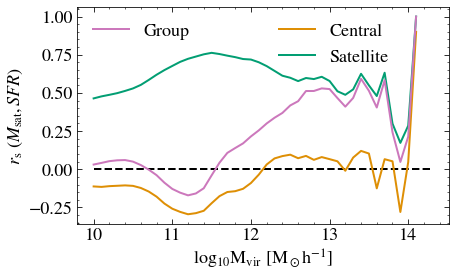

In [101]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", ncol=2)
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))

#plt.savefig("../figures/corr_coef_msat.pdf", format="pdf", bbox_inches="tight")

In [849]:
bins = np.arange(11,15,0.1)

frac_list = []
for m in bins:
    mask0 = (np.isnan(Mdyn) == False) & (mvir > m) & (mvir < m+0.1)
    masktot =  (mvir > m) & (mvir < m+0.1)
    frac = np.sum(mask0)/np.sum(masktot)
    frac_list.append(frac)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in long_scalars
  import sys


Text(0, 0.5, 'Frac(dMdyn is not nan)')

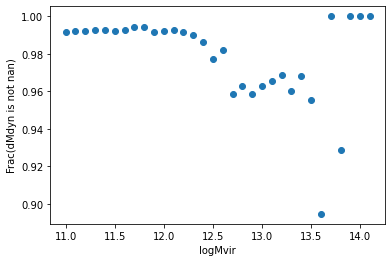

In [851]:
plt.scatter(bins, frac_list)
plt.xlabel("logMvir")
plt.ylabel("Frac(dMdyn is not nan)")

## Feature importance

In [13]:
#not sure if all these libraries are necessary for you
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
#from pprint import pprint
from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import confusion_matrix
from subprocess import call
import seaborn as sns
import pandas as pd


In [16]:
groupmass = np.log10(halos["GroupMass"]*1e10)

In [487]:
mask_data = (mvir > 12) & (mvir < 12.1)& (np.array(c200c) > 0) 

In [14]:
mask_data = (mvir > 12) & (mvir < 12.1)& (np.array(Mdyn) > 0) 

In [67]:
mask_data = (mvir > 12) & (mvir < 12.1)& (np.array(sum_sat_mass) > 0)  & (np.array(Mdyn) > 0) 

In [456]:
mask_nan = (np.isnan(np.array(c200c))) & (mvir> 11)

(array([1.3425e+04, 2.4910e+03, 5.6200e+02, 1.7600e+02, 6.1000e+01,
        1.8000e+01, 4.0000e+00, 2.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([11.000003, 11.072054, 11.144106, 11.216157, 11.288208, 11.36026 ,
        11.432311, 11.504362, 11.576413, 11.648465, 11.720516],
       dtype=float32),
 <BarContainer object of 10 artists>)

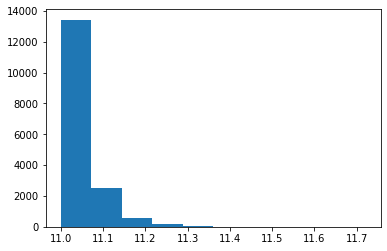

In [457]:
plt.hist(mvir[mask_nan])

(array([1.000e+00, 0.000e+00, 6.000e+00, 1.200e+01, 3.200e+01, 5.900e+01,
        1.280e+02, 2.330e+02, 3.880e+02, 5.850e+02, 9.670e+02, 1.289e+03,
        1.774e+03, 2.269e+03, 2.882e+03, 3.563e+03, 4.355e+03, 5.087e+03,
        5.828e+03, 6.347e+03, 7.154e+03, 7.545e+03, 8.222e+03, 8.303e+03,
        8.567e+03, 8.698e+03, 8.770e+03, 8.837e+03, 8.660e+03, 8.396e+03,
        8.321e+03, 7.840e+03, 7.412e+03, 7.059e+03, 6.748e+03, 6.222e+03,
        5.762e+03, 5.322e+03, 4.673e+03, 4.474e+03, 3.847e+03, 3.509e+03,
        3.135e+03, 2.810e+03, 2.490e+03, 2.174e+03, 1.938e+03, 1.677e+03,
        1.483e+03, 1.302e+03, 1.045e+03, 9.360e+02, 7.970e+02, 7.490e+02,
        6.130e+02, 5.300e+02, 4.920e+02, 3.710e+02, 3.830e+02, 2.650e+02,
        2.850e+02, 2.400e+02, 2.090e+02, 1.870e+02, 1.630e+02, 1.610e+02,
        1.140e+02, 9.000e+01, 6.900e+01, 7.800e+01, 7.300e+01, 6.400e+01,
        4.100e+01, 4.800e+01, 5.000e+01, 4.100e+01, 3.400e+01, 3.000e+01,
        2.600e+01, 2.400e+01, 2.400e+0

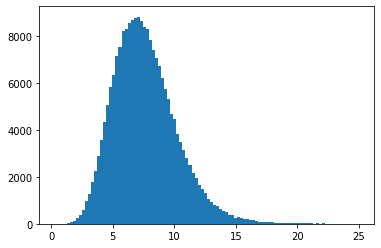

In [448]:
plt.hist(c200c[(mvir > 11) & (np.array(c200c) < 25)], bins=100)

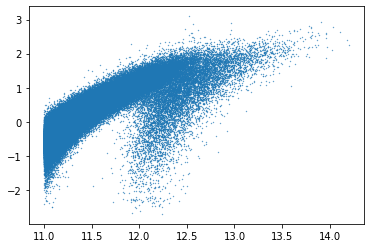

In [371]:
plt.scatter(mvir[mask_mass], group_sfr[mask_mass], s=0.1)

In [68]:
#Import the dataset 

#Label names of the columns are strings (ideally without spaces)
#LabelNames_orig = np.genfromtxt("data_3countries_genomeediting.csv",delimiter=",",dtype="str",max_rows=1)
#dataset_orig = np.genfromtxt("data_3countries_genomeediting.csv",delimiter=",",dtype="int",skip_header=1)
LabelNames_orig = ["SFR", "Mvir", "Msat", "Mdyn"]
dataset_orig = np.column_stack([sum_sfrs[mask_data], mvir[mask_data], sum_sat_mass[mask_data], np.array(Mdyn)[mask_data]])
LabelNames_orig_mass_only = ["SFR", "Mvir"]
dataset_orig_mass_only = np.column_stack([sum_sfrs[mask_data], mvir[mask_data]])

print(np.shape(LabelNames_orig))

print(np.shape(dataset_orig))
Ntot = np.shape(dataset_orig)[0]#Total number of samples
Ncol = np.shape(dataset_orig)[1]#Total number of columns/features
for i in range(Ncol):
    print(i,LabelNames_orig[i])

(4,)
(5201, 4)
0 SFR
1 Mvir
2 Msat
3 Mdyn


In [20]:
### Correlation analysis ###
def GetCorrMatrix(data_in,label_in,size=10, method="spearman"):
    
    df = pd.DataFrame(data_in, columns = label_in)
    matrix = df.corr(method=method).round(3)
    
    #delete unnecessary correlations
  #  matrix = matrix.drop(label_in[7:],axis=1)
   # matrix = matrix.drop(label_in[1:7],axis=0)
#    print(matrix)

    fig, ax = plt.subplots(figsize=(size,size))
    sns.heatmap(matrix, annot=True)
    plt.savefig("Correlation_Matrix.png",bbox_inches="tight")
    plt.show()
    plt.clf()
    return(matrix)

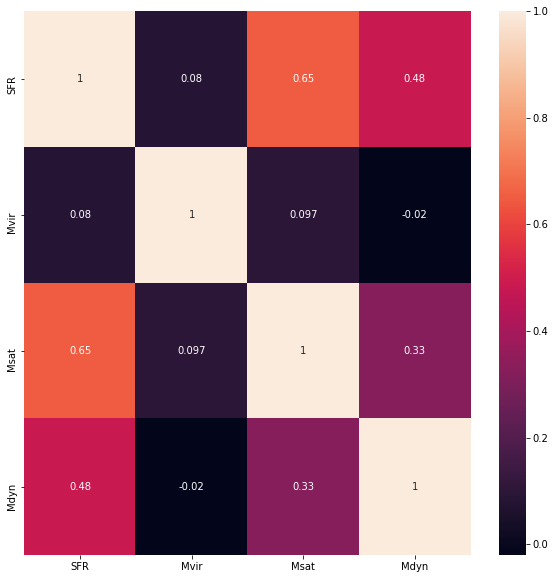

<Figure size 432x288 with 0 Axes>

In [64]:
method = "spearman"
X_corr = GetCorrMatrix(dataset_orig,LabelNames_orig,method=method)

In [23]:
### Decision Tree analysis ###
### Create decision tree to get feature importance ###


def GetFeatureImportance(dataset, LabelNames_orig):
    Ntot = np.shape(dataset)[0]
    
    y = dataset[:,0] #What we want to predict. Assuming SFR in column 0
    #make labels binary: split 50%/50%
    y_median = np.median(y)
    for i in range(Ntot):
        if(y[i] < y_median):
            y[i] = -1
        else:
            y[i] = 1
    #all other colums are features
    X = dataset[:,1:]
    LabelNames_orig = LabelNames_orig[1:]
    
    
    FI_sum = 0
    acc_sum = 0.
    N_sum = 0



    #Split the data into a training and a testing set

    Ntrain = int(0.9*Ntot)
    print("Ntrain=",Ntrain)

    train_features = X[:Ntrain,:]
    test_features = X[Ntrain:,:]
    train_targets = y[:Ntrain]
    test_targets = y[Ntrain:]


    #Train the model
    tree = DecisionTreeClassifier(criterion = 'gini',max_depth=8).fit(train_features,train_targets)
    FI_now = np.array(tree.feature_importances_)

    #Predict the classes of new, unseen data
    prediction = tree.predict(test_features)

    #Check the accuracy
    acc = tree.score(test_features,test_targets)
    acc = int(100*acc)
    print("The prediction accuracy is: ",acc,"%")


    #plot decision tree
    if(False):
        dot_file = 'tree.dot'
        skl.tree.export_graphviz(tree, out_file=dot_file, feature_names=LabelNames_orig)
        call(['dot', '-T', 'png', dot_file, '-o', 'v1_acc_'+str(acc)+'_tree.png'])


   # FI_sum = FI_sum#/np.sum(FI_sum)#option to normalise feature importance
    print("Feature Importance:")
    for i,label in enumerate(LabelNames_orig):
        print(label,np.round(100*FI_now[i],2),"%")
    print(" ")
    return 100*FI_now

In [65]:
FI = GetFeatureImportance(np.copy(dataset_orig_mass_only), LabelNames_orig_mass_only)

Ntrain= 4841
The prediction accuracy is:  43 %
Feature Importance:
Mvir 100.0 %
 


In [71]:
FI = GetFeatureImportance(np.copy(dataset_orig), LabelNames_orig)

Ntrain= 4680
The prediction accuracy is:  76 %
Feature Importance:
Mvir 7.06 %
Msat 63.27 %
Mdyn 29.67 %
 


In [488]:
median_conc = np.median(c200c[mask_data])
print(median_conc)

7.732859598031768


In [489]:
mask_high = c200c[mask_data] > median_conc
mask_low = c200c[mask_data] < median_conc

In [493]:
new_group_sfr = np.where(np.isinf(group_sfr[mask_data][mask_low]), -4,group_sfr[mask_data][mask_low])

ValueError: supplied range of [-inf, 2.2637248039245605] is not finite

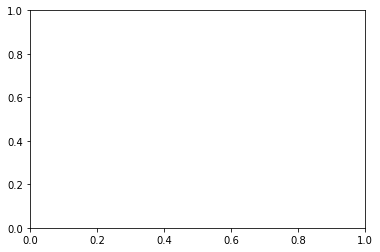

In [490]:
plt.hist(group_sfr[mask_data][mask_high], density=True, label="high conc", bins=20, alpha=0.5)
plt.hist(group_sfr[mask_data][mask_low], density=True, label="low conc", bins=20, alpha =0.5)
plt.legend()
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("PDF")

In [491]:
new_cent_sfr_low = np.where(np.isinf(cent_sfr[mask_data][mask_low]), -4,cent_sfr[mask_data][mask_low])

In [495]:
new_cent_sfr_high = np.where(np.isinf(cent_sfr[mask_data][mask_high]), -4,cent_sfr[mask_data][mask_high])

Text(0, 0.5, 'PDF')

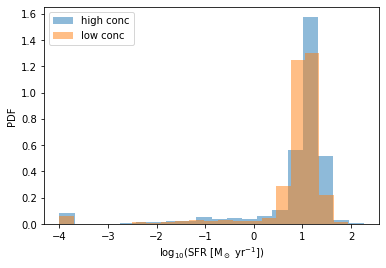

In [496]:
plt.hist(new_cent_sfr_high, density=True, label="high conc", bins=20, alpha=0.5)
plt.hist(new_cent_sfr, density=True, label="low conc", bins=20, alpha =0.5)
plt.legend()
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("PDF")